## Model Training Tracked with Mlflow


In [31]:
# check if everything here is needed
import mlflow
from mlflow import keras
from mlflow.models import infer_signature

import pandas as pd
from helper_functions import * 
import matplotlib.pyplot as plt
from keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.metrics import mean_squared_error
from keras.models import load_model

# Extract features from the test data
from sklearn.metrics import r2_score
from sklearn.metrics import explained_variance_score, mean_absolute_error

from mlflow.models import infer_signature

In [32]:
import os
# setting up credentials for storing the model
os.environ["AWS_ACCESS_KEY_ID"] = "eITEO5kyE7hccuy7UTHv"
os.environ["AWS_SECRET_ACCESS_KEY"] = "5KBCscit30Z70bSVGIMvMBBoqV8ydn232o2MW9RA"
os.environ["MLFLOW_S3_ENDPOINT_URL"] = f"http://172.1.0.12:2000"

In [33]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")
mlflow.start_run(run_name='LSTM_Model_Training')

<ActiveRun: >

## Data Prep

In [34]:
# Data preperation
file_path = 'kraken_ohlc_hour.csv'
lstm_data = pd.read_csv(file_path)
#print(lstm_data)
lstm_data = lstm_data.drop(columns=['open_price', 'high', 'low'], axis=1)

lstm_data = process_timestamp(lstm_data)
lstm_data = add_feature_date(lstm_data)
lstm_data = add_feature_lag(lstm_data, lags=[12, 168])
lstm_data = add_holiday_feature(lstm_data)
lstm_data = apply_cyclic_encoding(lstm_data)
lstm_data = apply_day_of_month_encoding(lstm_data)
lstm_data = normalize_year(lstm_data) # has to be updated yearly 
lstm_data = apply_log_scaler(lstm_data)

lstm_data = lstm_data.drop(columns=['bucket','hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)

lstm_data.head()

#cycle_length = get_distinct_count(data, 'hour')
#lstm_data['hour_sin'] = lstm_data['hour'].apply(lambda x: encode_cyclic_feature(x, cycle_length)).astype(float)

,close_price,volume,is_weekend,close_lag12,close_lag168,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
168,1.099205,3.931159,0,1.085189,1.386294,0,-8.660254e-01,-0.500000,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
169,1.099205,0.000000,0,1.071584,1.386294,0,-7.071068e-01,-0.707107,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
170,1.073096,2.638756,0,1.071584,1.386294,0,-5.000000e-01,-0.866025,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
171,1.033184,5.380558,0,1.071584,1.386297,0,-2.588190e-01,-0.965926,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0
172,1.057790,5.303305,0,1.071584,1.386297,0,-1.836970e-16,-1.000000,-0.900969,-0.433884,-0.5,-0.866025,0.485302,-0.874347,0.0


In [35]:
def create_sequences_np(data, features, lookback):
    data_array = data[features].to_numpy()
    X, y = [], []
    for i in range(lookback, len(data_array)):
        X.append(data_array[i-lookback:i])
        y.append(data_array[i, data.columns.get_loc('close_price')])
    return np.array(X), np.array(y)

features = ['close_price', 'volume', 'is_weekend', 'close_lag12', 'close_lag168', 
            'is_holiday', 'hour_cos', 'hour_sin', 'day_of_week_cos', 
            'day_of_week_sin', 'month_cos', 'month_sin', 
            'day_of_month_sin', 'day_of_month_cos', 'year_normalized']

lookback = 1
X, y = create_sequences_np(lstm_data, features, lookback)

## Model Training

In [36]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

n_features = len(features)  # Number of features used
epochs = 1 
units_lstm_1 = 50
units_lstm_2 = 50
dropout_layer_1 = 0.2
dropout_layer_2 = 0.2

return_sequences_lstm_1 = True
return_sequences_lstm_2 = False

dense_units = 1 

optimizer = 'adam'
loss = 'mean_squared_error'

training_validation_split = 0.8

batch_size = 32

mlflow.log_param('lookback', lookback)
mlflow.log_param('n_features', n_features)
mlflow.log_param('features', features)
mlflow.log_param('epochs', epochs)
mlflow.log_param('units_lstm_1', units_lstm_1)
mlflow.log_param('units_lstm_2', units_lstm_2)
mlflow.log_param('return_sequences_lstm', return_sequences_lstm_1)
mlflow.log_param('optimizer', optimizer)
mlflow.log_param('loss', loss)
mlflow.log_param('training_validation_split', training_validation_split)
mlflow.log_param('batch_size', batch_size)


# LSTM model
model = Sequential()
model.add(LSTM(units=units_lstm_1,return_sequences=return_sequences_lstm_1, input_shape=(lookback, n_features))) # 1
model.add(Dropout(dropout_layer_1))
model.add(LSTM(units=units_lstm_1, return_sequences=return_sequences_lstm_2)) # 2
model.add(Dropout(dropout_layer_2))
model.add(Dense(units=dense_units))

model.compile(optimizer=optimizer, loss=loss)

# split point at 20 percent 
split_idx = int(len(X) * training_validation_split)

# validation set with the last 20 percent of the dataset 
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

# maybe 43 epochs seems to have a good loss 
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val))

# storage issue 


1781/1781 [==============================] - 11s 5ms/step - loss: 0.9167 - val_loss: 0.0176


In [37]:
## load non-training data: + 12hour lookback 

# Data preperation
test_lstm = pd.read_csv('test_data.csv')
original_lstm_test = test_lstm.copy()
#print(lstm_data)
test_lstm = test_lstm.drop(columns=['open_price', 'high', 'low'], axis=1)

test_lstm = process_timestamp(test_lstm)
test_lstm = add_feature_date(test_lstm)
test_lstm = add_feature_lag(test_lstm, lags=[12, 168])
test_lstm = add_holiday_feature(test_lstm)
test_lstm = apply_cyclic_encoding(test_lstm)
test_lstm = apply_day_of_month_encoding(test_lstm)
test_lstm = normalize_year(test_lstm) # has to be updated yearly 
test_lstm = apply_log_scaler(test_lstm)

test_lstm = test_lstm.drop(columns=['hour', 'day_of_week', 'day_of_month', 'month', 'year'], axis=1)

test_lstm.head()

,bucket,close_price,volume,is_weekend,close_lag12,close_lag168,is_holiday,hour_cos,hour_sin,day_of_week_cos,day_of_week_sin,month_cos,month_sin,day_of_month_sin,day_of_month_cos,year_normalized
168,2023-09-29 10:00:00+00:00,7.37461,0.0,0,7.37461,7.374240,0,-0.866025,5.000000e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
169,2023-09-29 11:00:00+00:00,7.37461,0.0,0,7.37461,7.376458,0,-0.965926,2.588190e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
170,2023-09-29 12:00:00+00:00,7.37461,0.0,0,7.37461,7.375381,0,-1.000000,1.224647e-16,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
171,2023-09-29 13:00:00+00:00,7.37461,0.0,0,7.37461,7.375788,0,-0.965926,-2.588190e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0
172,2023-09-29 14:00:00+00:00,7.37461,0.0,0,7.37461,7.377590,0,-0.866025,-5.000000e-01,1.0,-4.898587e-16,1.0,-2.204364e-15,-0.406737,0.913545,0.0


1/1 [==============================] - 0s 14ms/step


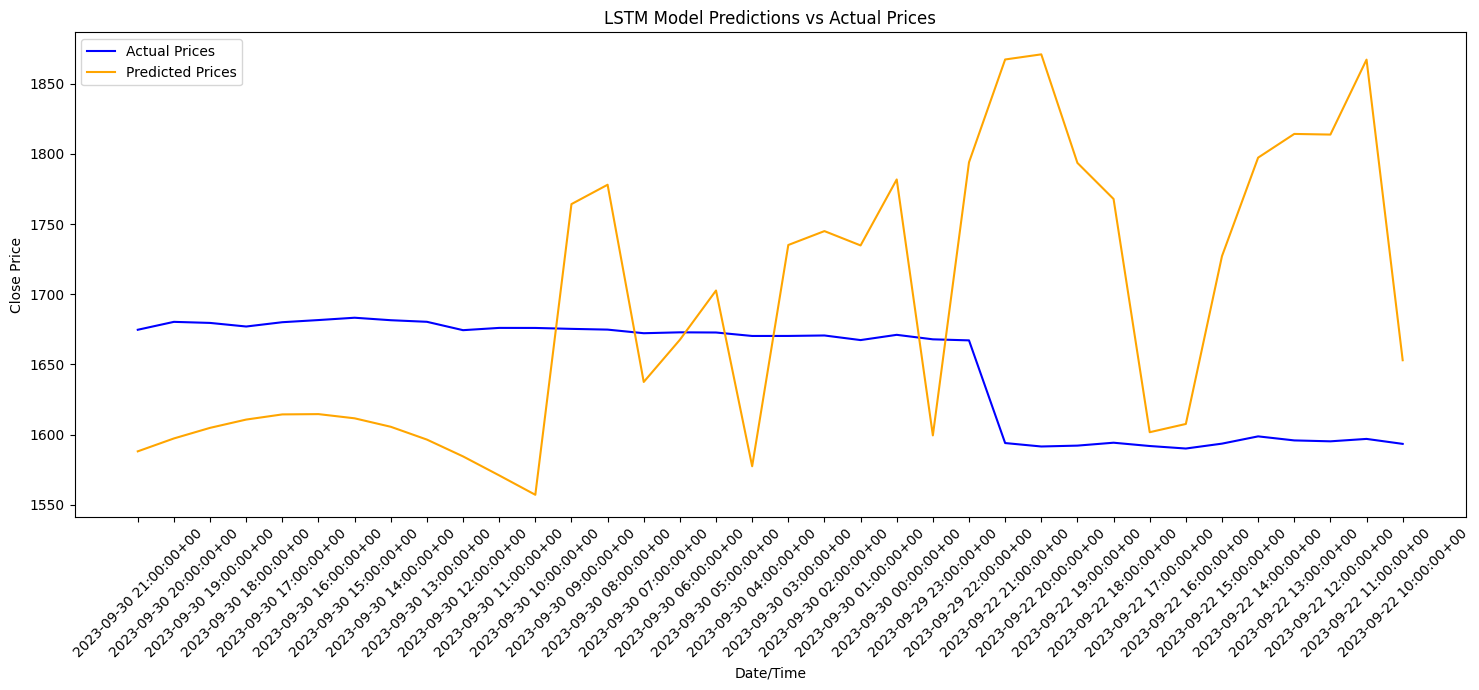

In [38]:
features = ['close_price', 'volume', 'is_weekend', 'close_lag12', 'close_lag168',
            'is_holiday', 'hour_cos', 'hour_sin', 'day_of_week_cos',
            'day_of_week_sin', 'month_cos', 'month_sin',
            'day_of_month_sin', 'day_of_month_cos', 'year_normalized']


# Start the loop to predict each next hour and collect the actual and predicted prices
predicted_prices = []
actual_prices = original_lstm_test['close_price'].values[lookback:]  # actual prices without log transformation
timestamps = original_lstm_test['bucket'].values[lookback:]  # corresponding timestamps

for i in range(lookback, len(test_lstm)):
    last_sequence = test_lstm.iloc[i-lookback:i][features].values.reshape((1, lookback, len(features)))
    predicted_log_price = model.predict(last_sequence)
    predicted_price = np.expm1(predicted_log_price)[0, 0]  # inverse log transformation
    predicted_prices.append(predicted_price)

# Convert predictions to a numpy array
predicted_prices = np.array(predicted_prices)

# Calculate the metrics
mse_value = mean_squared_error(actual_prices, predicted_prices)
mae_value = mean_absolute_error(actual_prices, predicted_prices)
rmse_value = np.sqrt(mse_value)
mape_value = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100
r2_value = r2_score(actual_prices, predicted_prices)
explained_variance = explained_variance_score(actual_prices, predicted_prices)

mlflow.log_metric('mse', mse_value)
mlflow.log_metric('mae', mae_value)
mlflow.log_metric('rmse', rmse_value)
mlflow.log_metric('mape', mape_value)
mlflow.log_metric('r2', r2_value)
mlflow.log_metric('explained_variance', explained_variance)

# Plotting the results
plt.figure(figsize=(15, 7))
plt.plot(timestamps, actual_prices, label='Actual Prices', color='blue')
plt.plot(timestamps, predicted_prices, label='Predicted Prices', color='orange')
plt.xlabel('Date/Time')
plt.ylabel('Close Price')
plt.title('LSTM Model Predictions vs Actual Prices')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()  # Adjusts plot to ensure everything fits without overlapping
plt.show()


In [39]:
signature = infer_signature(actual_prices, predicted_prices)

mlflow.sklearn.log_model(
    sk_model=model,
    artifact_path="sklearn-model",
    signature=signature,
    registered_model_name="test_model",
)

Registered model 'test_model' already exists. Creating a new version of this model...
2023/11/25 14:48:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: test_model, version 3
Created version '3' of model 'test_model'.


In [40]:
mlflow.end_run()